In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: light
#       format_version: '1.5'
#       jupytext_version: 1.16.3
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---

# # 🌟 **Ejercicio Práctico: Introducción a ROS y Robótica con Python**
# ## **Módulo: Visión por Computadora + Robótica Colaborativa**
# ---
# 
# **Objetivo del ejercicio:**  
# Simular un **robot colaborativo (cobot)** que utiliza **visión por computadora** para detectar objetos en una mesa de trabajo y calcular su posición relativa para manipulación segura.
# 
# **Temas integrados:**
# - Procesamiento de imágenes (`OpenCV`)
# - Detección de contornos y momentos
# - Cálculo de centroides y distancias
# - Simulación de seguridad (zona de trabajo compartida)
# - Publicación de datos tipo **ROS** (estructura de mensajes)
# 
# ---

In [2]:
# ## 1. Instalación de librerías (ejecutar una sola vez)
# !pip install opencv-python numpy matplotlib

In [3]:
# ## 2. Importar librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
import json
import time

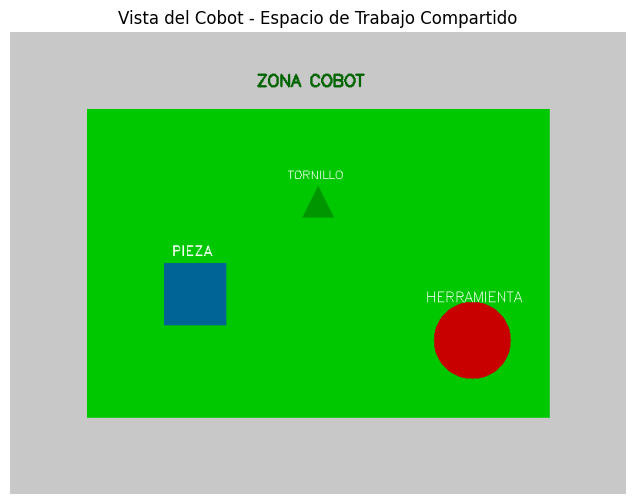

In [4]:
# ## 3. Simulación de captura de imagen (reemplaza con cámara real si tienes una)
# Generamos una imagen sintética que simula la vista de un cobot
def generar_imagen_trabajo(ancho=800, alto=600):
    img = np.ones((alto, ancho, 3), dtype=np.uint8) * 200  # Fondo gris claro (mesa)
    
    # Zona segura del cobot (rectángulo verde)
    cv2.rectangle(img, (100, 100), (700, 500), (0, 200, 0), -1)
    cv2.putText(img, 'ZONA COBOT', (320, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 100, 0), 2)
    
    # Objetos en la mesa
    # Pieza metálica (rectángulo azul)
    cv2.rectangle(img, (200, 300), (280, 380), (150, 100, 0), -1)
    cv2.putText(img, 'PIEZA', (210, 290), cv2.FONT_HERSHEY_DUPLEX, 0.6, (255, 255, 255), 1)
    
    # Herramienta humana (círculo rojo - ¡ALERTA!)
    cv2.circle(img, (600, 400), 50, (0, 0, 200), -1)
    cv2.putText(img, 'HERRAMIENTA', (540, 350), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
    
    # Tornillo pequeño (triángulo verde)
    pts = np.array([[400, 200], [420, 240], [380, 240]], np.int32)
    cv2.fillPoly(img, [pts], (0, 150, 0))
    cv2.putText(img, 'TORNILLO', (360, 190), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    
    return img

# Mostrar imagen
img_trabajo = generar_imagen_trabajo()
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_trabajo, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Vista del Cobot - Espacio de Trabajo Compartido")
plt.show()

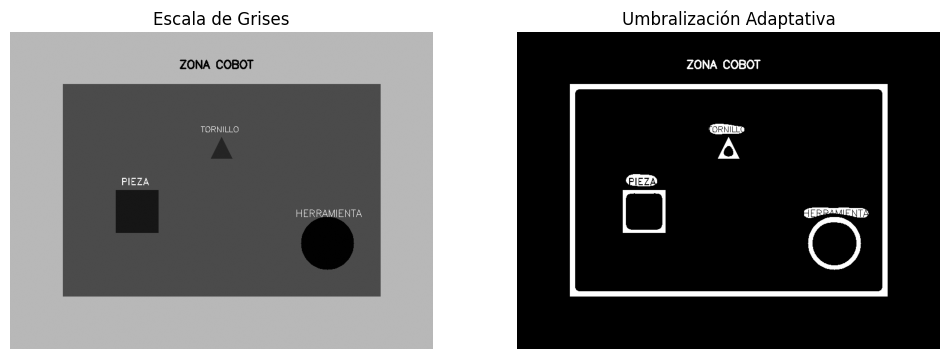

In [5]:
# ## 4. Preprocesamiento: Convertir a escala de grises y umbralización
gray = cv2.cvtColor(img_trabajo, cv2.COLOR_BGR2GRAY)

# Umbralización adaptativa para detectar objetos oscuros sobre fondo claro
thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                               cv2.THRESH_BINARY_INV, 51, 10)

# Mostrar resultado
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Escala de Grises')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(thresh, cmap='gray')
plt.title('Umbralización Adaptativa')
plt.axis('off')
plt.show()

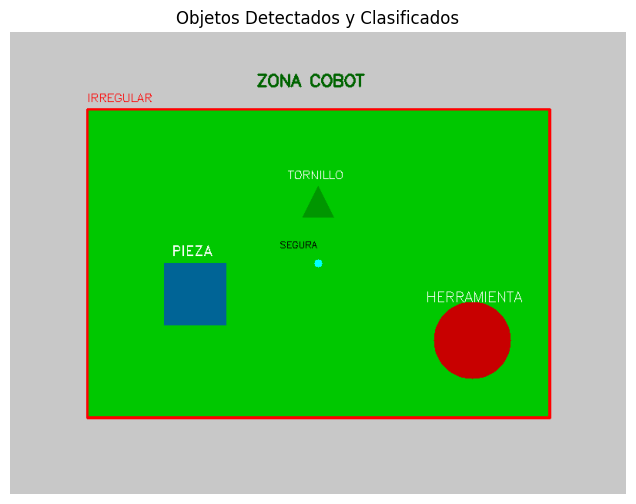

In [6]:
# ## 5. Detección de contornos y análisis de objetos
contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Copia para dibujar
img_contornos = img_trabajo.copy()
objetos_detectados = []

for i, cnt in enumerate(contornos):
    area = cv2.contourArea(cnt)
    if area > 500:  # Filtrar ruido
        # Momentos para calcular centroide
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = 0, 0
        
        # Bounding box
        x, y, w, h = cv2.boundingRect(cnt)
        
        # Clasificación simple por forma
        aspecto = w / float(h)
        if 0.8 <= aspecto <= 1.2:
            tipo = "CUADRADO/PIEZA"
            color = (255, 0, 0)
        elif aspecto > 1.5:
            tipo = "RECTANGULAR"
            color = (0, 255, 0)
        else:
            tipo = "IRREGULAR"
            color = (0, 0, 255)
        
        # Verificar si está en zona segura del cobot
        en_zona_segura = (100 < cx < 700) and (100 < cy < 500)
        estado = "SEGURA" if en_zona_segura else "¡ALERTA! Fuera de zona"
        
        # Dibujar
        cv2.drawContours(img_contornos, [cnt], -1, color, 2)
        cv2.rectangle(img_contornos, (x, y), (x+w, y+h), color, 2)
        cv2.circle(img_contornos, (cx, cy), 5, (255, 255, 0), -1)
        cv2.putText(img_contornos, f'{tipo}', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        cv2.putText(img_contornos, estado, (cx-50, cy-20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,0), 1)
        
        # Guardar datos del objeto
        objetos_detectados.append({
            "id": i+1,
            "tipo": tipo,
            "centroide": (cx, cy),
            "area": area,
            "en_zona_segura": en_zona_segura,
            "distancia_centro_mesa": np.sqrt((cx - 400)**2 + (cy - 300)**2)
        })

# Mostrar
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_contornos, cv2.COLOR_BGR2RGB))
plt.title("Objetos Detectados y Clasificados")
plt.axis('off')
plt.show()

In [7]:
# ## 6. Simulación de mensaje ROS (estructura tipo /objetos_detectados)
class ROSMessageSimulator:
    def __init__(self):
        self.topic = "/cobot/objetos_detectados"
        self.timestamp = time.time()
    
    def publicar(self, datos):
        mensaje = {
            "header": {
                "stamp": self.timestamp,
                "frame_id": "cobot_camera"
            },
            "objetos": datos
        }
        print(f"\n📡 Publicando en {self.topic}")
        print(json.dumps(mensaje, indent=2)[:500] + "...")

# Publicar resultados como si fuera ROS
ros_sim = ROSMessageSimulator()
ros_sim.publicar(objetos_detectados)


📡 Publicando en /cobot/objetos_detectados
{
  "header": {
    "stamp": 1762777281.6200628,
    "frame_id": "cobot_camera"
  },
  "objetos": [
    {
      "id": 1,
      "tipo": "IRREGULAR",
      "centroide": [
        400,
        300
      ],
      "area": 240000.0,
      "en_zona_segura": true,
      "distancia_centro_mesa": 0.0
    }
  ]
}...


In [8]:
# ## 7. Análisis de seguridad y decisión del cobot
print("🤖 DECISIONES DEL COBOT:\n")
for obj in objetos_detectados:
    if not obj["en_zona_segura"]:
        print(f"⚠️  OBJETO {obj['id']} ({obj['tipo']}): FUERA DE ZONA SEGURA → DETENER BRAZO")
    elif obj["tipo"] == "CUADRADO/PIEZA":
        print(f"✅ OBJETO {obj['id']}: PIEZA LISTA → INICIAR MANIPULACIÓN")
    else:
        print(f"🔍 OBJETO {obj['id']}: ANALIZAR ANTES DE MOVER")

🤖 DECISIONES DEL COBOT:

🔍 OBJETO 1: ANALIZAR ANTES DE MOVER


In [10]:
# ## 8. Tarea para el estudiante
print("""
## **TAREA FINAL: Mejora el Sistema**

Completa **una** de las siguientes mejoras:

1. **Detección de color** → Usa `cv2.inRange()` para identificar objetos por color (ej: tornillos verdes).
2. **Cálculo de trayectoria** → Usa el centroide para generar una trayectoria suave al efector final.
3. **Simulación ROS real** → Conecta con ROS Noetic/ROS2 y publica en un tópico real.
4. **Zona dinámica** → Haz que la zona segura cambie según la posición del operario (simulado).

¡Sube tu versión mejorada a GitHub y compártela!
""")


## **TAREA FINAL: Mejora el Sistema**

Completa **una** de las siguientes mejoras:

1. **Detección de color** → Usa `cv2.inRange()` para identificar objetos por color (ej: tornillos verdes).
2. **Cálculo de trayectoria** → Usa el centroide para generar una trayectoria suave al efector final.
3. **Simulación ROS real** → Conecta con ROS Noetic/ROS2 y publica en un tópico real.
4. **Zona dinámica** → Haz que la zona segura cambie según la posición del operario (simulado).

¡Sube tu versión mejorada a GitHub y compártela!

